In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import seaborn as sns
from scipy import sparse

### Objectif du projet

L'objectif de ce projet est de créer un systéme de recommendation qui recommande les meilleures configurations ou composants pour construire un robot en fonction des besoins spécifiques de l'utilisateur.

### Chargement et pré-traitement des données

In [3]:
datasets = pd.read_csv('../data/products_dataset.csv')
datasets.head()

,name,vendor,link,price,description,characteristics,reviews
0,Contrôleur Leap Motion 2 Ultraleap,Ultraleap,https://eu.robotshop.com//fr/products/controle...,"Prix en promotion€250,07",La deuxième génération de la caméra de suivi d...,Alimentation électrique requise : 5VDC via USB...,Average rating is 0.00 stars
1,Contrôleur Leap Motion,Ultraleap,https://eu.robotshop.com//fr/products/controle...,"Prix en promotion€144,93",Le Contrôleur Leap Motion est un module de sui...,FOV: 150x120 degrés Portée: variable (sans lie...,Average rating is 4.74 stars
2,Support pour casque XR pour contrôleur Leap Mo...,Ultraleap,https://eu.robotshop.com//fr/products/support-...,"Prix en promotion€23,05",Ajoutez facilement le meilleur suivi des mains...,Angle d'inclinaison vers le bas : 15° Matière ...,Average rating is 0.00 stars
3,Contrôleur de Moteur Intelligent 2 Canaux 30A ...,Cytron,https://eu.robotshop.com//fr/products/controle...,"Prix en promotion€87,94",Le Contrôleur de Moteur Intelligent 2 Canaux 3...,"Entrée compatible : 3,3 et 5 V Canaux de moteu...",Average rating is 4.71 stars
4,Contrôleur de Moteur Regénératif Sabertooth 2x...,Dimension Engineering,https://eu.robotshop.com//fr/products/controle...,"Prix en promotion€133,58",Le Contrôleur de Moteur Régénératif Sabertooth...,"32A continu, 64A crête par canal Tension : de ...",Average rating is 4.85 stars


In [4]:
datasets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7515 entries, 0 to 7514
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   name             7515 non-null   object
 1   vendor           7515 non-null   object
 2   link             7515 non-null   object
 3   price            873 non-null    object
 4   description      775 non-null    object
 5   characteristics  612 non-null    object
 6   reviews          874 non-null    object
dtypes: object(7)
memory usage: 411.1+ KB


**Observation :**

On observe un nombre important de données manquantes, ceci est dù au scrapping.
En effet, les données proviennent de `https://eu.robotshop.com//fr/products/` mais malheureusemnt, je n'ai pas pu scrapper toutes
les infos que je voulais. 

Par la suite, je vais me baser sur la colonne description pour filtrer les données manquantes. **Pourquoi?**
- Dans un système de recommandation basé sur le contenu, les descriptions contiennent souvent des mots-clés ou des informations importantes sur les produits.
- Si un produit n'a pas de description, il sera difficile de l'associer à d'autres produits ou de le recommander en fonction des besoins.
- la qualité à la quantité... :-)

On se retrouvera avec 181 characteristics nulles, mais vu que la colonne n'a pas trop d'importances, je vais remplacer les valeurs nulles par un texte.


**Suppresion des données manquants :** 

In [5]:
data_cleaned = datasets.dropna(subset=['description'])  
data_cleaned = data_cleaned.replace(np.nan,'Non specifié',regex=True).reset_index(drop=True)
data_cleaned.shape

(775, 7)

In [6]:
data_cleaned.isnull().sum()

name               0
vendor             0
link               0
price              0
description        0
characteristics    0
reviews            0
dtype: int64

***Parfait!*** passons aux netoyages des colonnes : *price* et *reviews*.

**Extractions des chiffres dans *price* et *reviews***

In [7]:
data_cleaned['price'] = data_cleaned['price'].str.replace(r'[^\d,]', '', regex=True)
data_cleaned['price'].replace('' , 0, inplace=True)  # Rempli par 0 si la ligne n'avait pas de valeurs initialement
data_cleaned['reviews'] = data_cleaned['reviews'].str.replace(r'[^\d.]', '', regex=True)

/var/folders/rt/dwbktyq55txcqynyl32k560r0000gn/T/ipykernel_16727/564537715.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned['price'].replace('' , 0, inplace=True)  # Rempli par 0 si la ligne n'avait pas de valeurs initialement


In [8]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775 entries, 0 to 774
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   name             775 non-null    object
 1   vendor           775 non-null    object
 2   link             775 non-null    object
 3   price            775 non-null    object
 4   description      775 non-null    object
 5   characteristics  775 non-null    object
 6   reviews          775 non-null    object
dtypes: object(7)
memory usage: 42.5+ KB


In [9]:
## On va aussi convertir ces deux colonnes au bon format
data_cleaned['price'] = data_cleaned['price'].str.replace(',', '.').astype(float)
data_cleaned['reviews'] = data_cleaned['reviews'].astype(float)

**Concaténation de colonnes pour avoir le max d'informations**

In [10]:
data_cleaned['description'] = data_cleaned.description.str.lower()
data_cleaned['characteristics'] = data_cleaned.characteristics.str.lower()
data_cleaned['combined_info'] = (
    "description: " + data_cleaned['description'] + " | " +
    "caractéristiques: " + data_cleaned['characteristics'] + " | " +
    "prix: " + np.log1p(data_cleaned['price']).round(2).astype(str)
)

**Catégorisation des produits**

In [49]:
def categorize_product(text:str):
    components = ['capteur', 'détecteur', 'sonde',
                 'moteur', 'servomoteur', 'actuateur',
                 'batterie', 'chargeur',
                 'câble', 'connecteurs', 'fils', 'adaptateur',
                 'contrôleur', 'driver', 'controller',
                 'microcontrôleur', 'arduino', 'raspberry pi',
                 'affichage', 'lcd', 'écran' 
                 ]
    text_lower = text.lower().split()
    for comp in text_lower :
        if comp in components:
            return comp
    return None

In [50]:
data_cleaned['category'] = data_cleaned['name'].apply(categorize_product)

In [51]:
data_cleaned.head()

,name,vendor,link,price,description,characteristics,reviews,combined_info,category,price_log
0,Contrôleur Leap Motion 2 Ultraleap,Ultraleap,https://eu.robotshop.com//fr/products/controle...,250.07,la deuxième génération de la caméra de suivi d...,alimentation électrique requise : 5vdc via usb...,0.00,description: la deuxième génération de la camé...,contrôleur,5.525732
1,Contrôleur Leap Motion,Ultraleap,https://eu.robotshop.com//fr/products/controle...,144.93,le contrôleur leap motion est un module de sui...,fov: 150x120 degrés portée: variable (sans lie...,4.74,description: le contrôleur leap motion est un ...,contrôleur,4.983127
2,Support pour casque XR pour contrôleur Leap Mo...,Ultraleap,https://eu.robotshop.com//fr/products/support-...,23.05,ajoutez facilement le meilleur suivi des mains...,angle d'inclinaison vers le bas : 15° matière ...,0.00,description: ajoutez facilement le meilleur su...,contrôleur,3.180135
3,Contrôleur de Moteur Intelligent 2 Canaux 30A ...,Cytron,https://eu.robotshop.com//fr/products/controle...,87.94,le contrôleur de moteur intelligent 2 canaux 3...,"entrée compatible : 3,3 et 5 v canaux de moteu...",4.71,description: le contrôleur de moteur intellige...,contrôleur,4.487962
4,Contrôleur de Moteur Regénératif Sabertooth 2x...,Dimension Engineering,https://eu.robotshop.com//fr/products/controle...,133.58,le contrôleur de moteur régénératif sabertooth...,"32a continu, 64a crête par canal tension : de ...",4.85,description: le contrôleur de moteur régénérat...,contrôleur,4.902159


In [60]:
# Sauvegarde le dataframe final
data_cleaned.to_csv('../data/product_cleaned_.csv',index=False)

### Visualisation des données

**les 10 plus gros vendeurs de produits**

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'DFRobot'),
  Text(1, 0, 'M5Stack'),
  Text(2, 0, 'Sparkfun Electronics'),
  Text(3, 0, 'Phidgets'),
  Text(4, 0, 'Lynxmotion'),
  Text(5, 0, 'Cytron'),
  Text(6, 0, 'Actuonix'),
  Text(7, 0, 'Pololu'),
  Text(8, 0, 'ArduCAM'),
  Text(9, 0, 'SeeedStudio')])

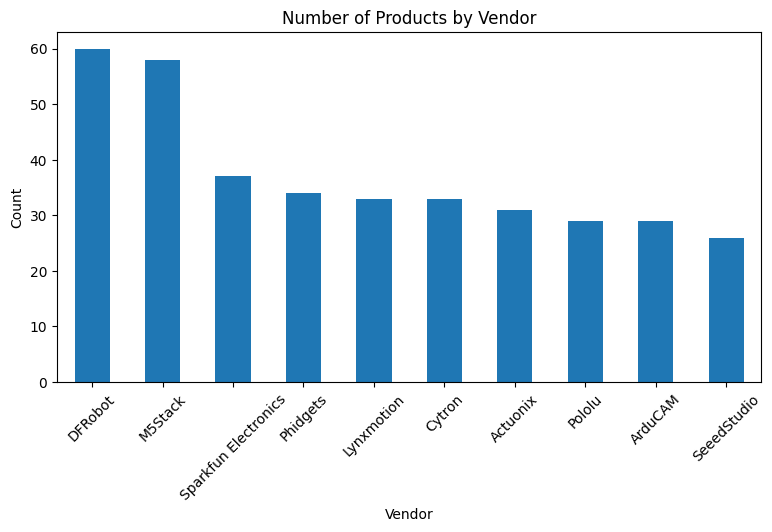

In [17]:
fig = plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
_ = data_cleaned['vendor'].value_counts().head(10).plot(kind='bar')
plt.title('Number of Products by Vendor')
plt.xlabel('Vendor')
plt.ylabel('Count')
plt.xticks(rotation=45)

**Distribution des prix**

<Axes: xlabel='price'>

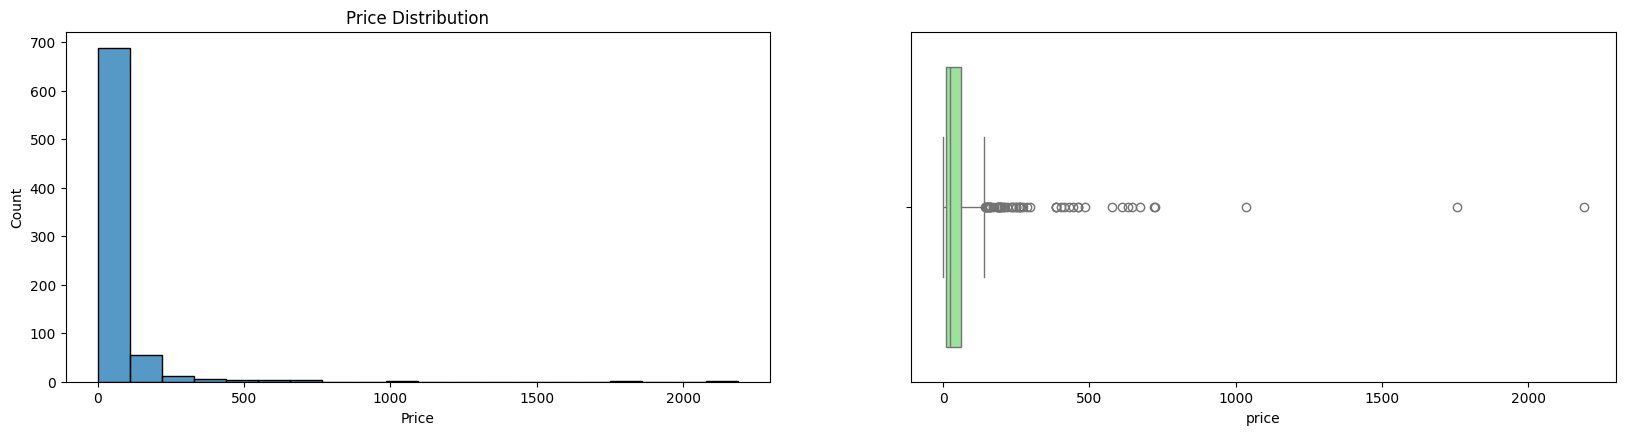

In [18]:
fig = plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 3)
sns.histplot(data_cleaned['price'], bins=20)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.subplot(2, 2, 4)
sns.boxplot(data=data_cleaned, x='price', color='lightgreen')

*Observation :*

- La majorité des produits ont un prix très bas, inférieur à 500. On remarque une forte concentration autour des prix bas.
-  Très peu de produits se trouvent dans des plages de prix élevées, ce qui explique les barres presque invisibles au-delà de 500.
- La boîte (vert clair) indique que la majorité des prix (interquartiles, Q1-Q3) se situe en dessous de 250. La médiane est également très basse.
- Les points au-dessus de 500 représentent des valeurs **aberrantes**. Certains produits ont des prix très élevés (jusqu'à 2000), mais ils sont rares.

Pour eviter que des valeurs extrêmes biaisent mes calculs ou recommandations, je vais appliquer une transformation logarithmique à la colonne *price*.



In [19]:
data_cleaned['price_log'] = np.log1p(data_cleaned['price'])

**Distribution des reviews**

Text(0, 0.5, 'Review Score')

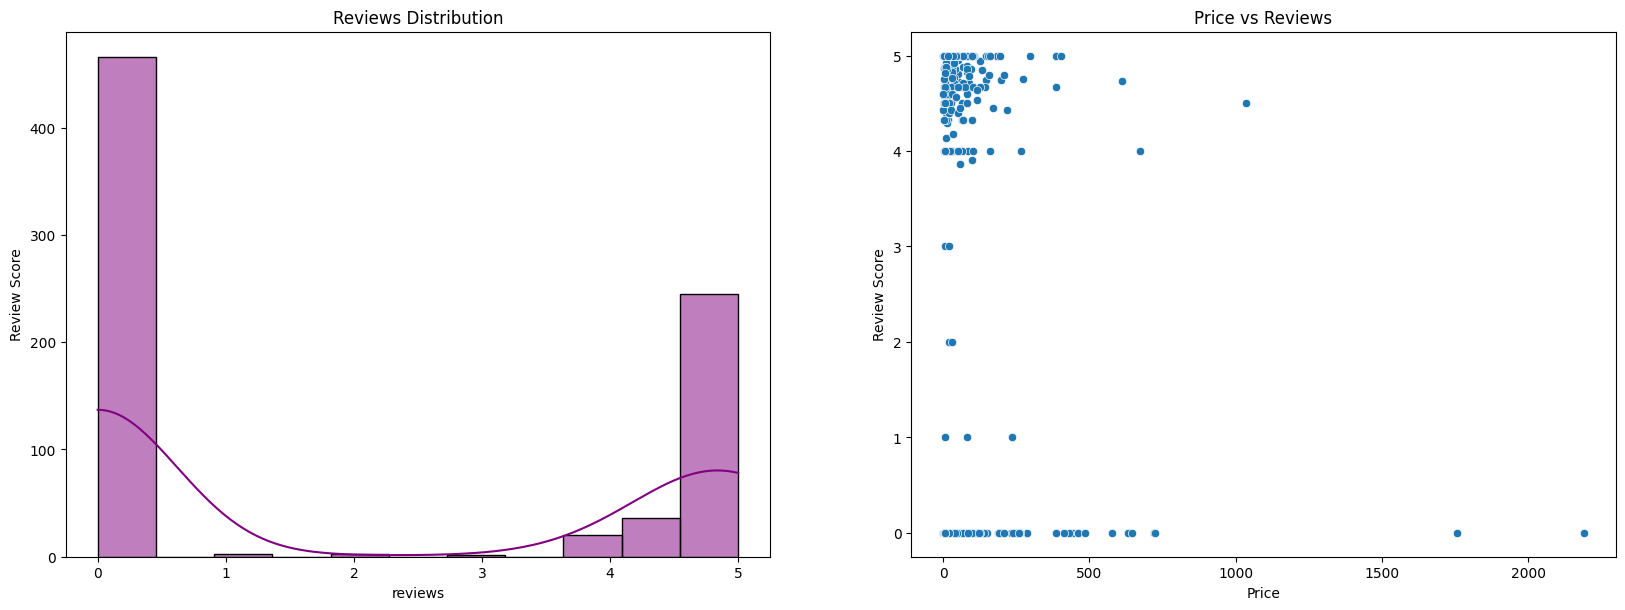

In [20]:
fig = plt.figure(figsize=(20, 15))
plt.subplot(2,2,3)
sns.histplot(data_cleaned['reviews'], kde=True, color='purple')
plt.title('Reviews Distribution')
plt.ylabel('Review Score')
# 4. Price vs Reviews Scatter Plot
plt.subplot(2, 2, 4)
sns.scatterplot(x=data_cleaned['price'], y=data_cleaned['reviews'])
plt.title('Price vs Reviews')
plt.xlabel('Price')
plt.ylabel('Review Score')

- La majorité des produits ont soit un score de reviews très faible (près de 0), soit un score très élevé (près de 5). Cette distribution bimodale indique que les produits tendent à être très appréciés ou peu appréciés, sans beaucoup de valeurs intermédiaires.
- La majorité des produits avec un prix faible (en dessous de 500) ont des scores de reviews concentrés près de 5, mais certains ont également des scores proches de 0.

In [21]:
correlation = data_cleaned['price_log'].corr(data_cleaned['reviews'])
print(f'Correlation between log(price) and reviews: {correlation}')

Correlation between log(price) and reviews: -0.002204840916513987


### Préparation du système de recommandation (content based-model)

On va Vectoriser la colonne *combined_info* en utilisant **TF-IDF** (Term Frequency-Inverse Document Frequency), Très utilisé pour capturer l'importance des mots dans le contexte du dataset.

**Vectorisation des mots**

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(data_cleaned['combined_info'])
tfidf_matrix.shape

(775, 9290)

In [62]:
import pickle

with open("../src/features/tfidf_model_product.pkl", "wb") as f:
    pickle.dump(tfidf, f)

In [64]:
sparse.save_npz('../src/features/tfidf_products_description_matrix.npz', tfidf_matrix)


**Similarité entre deux produits**

Pour pouvoir recommender un produit convenable à ce que l'utisateur souhaite, il nous faut une méthode qui nous permet de méusrer la simularité entre l'entrée de l'utilisateur et les produits qu'on a à notre disposition. Plusieurs méthodes existes mais nous allons utiliser la méthode de **similarité cosinus**.

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

cosines_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [25]:
cosines_sim.shape

(775, 775)

**Implementation d'une fonction qui retourne les recommendations**

In [56]:
from typing import Optional

def recommend_by_category(description: str, category:str, budget: Optional[int] = None):
    # Étape 1 : Prétraitement de la description utilisateur
    description_cleaned = description.lower()
    combined_input = ["description: " + description_cleaned]
    if budget:
        combined_input.append(" | prix: " + str(np.log1p(budget).round(2)))
    
    # Vectorisation
    vectorised_input = tfidf.transform(combined_input)
    similarities = cosine_similarity(vectorised_input, tfidf_matrix)[0]
    
    # Étape 2 : Structure les recommandations par catégorie
    recommendations = {}
    category_indices = data_cleaned[
        (data_cleaned['category'] == category) & 
        (data_cleaned['price'] <= budget)].index
    
    # si catégorie inexistante
    if not category_indices.any():
        return {category: [{"message": "Aucun produit trouvé dans cette catégorie avec ce budget."}]}
        
    category_similarities = [(i, similarities[i]) for i in category_indices]
    category_similarities = sorted(category_similarities, key=lambda x: x[1], reverse=True)
    
    # Prend les 3 meilleurs produits pour cette catégorie
    recommendations[category] = [
        {
            "name": data_cleaned.loc[i, "name"],
            "price": data_cleaned.loc[i, "price"],
            "score": sim
        }
        for i, sim in category_similarities[:3]
    ]
    
    return recommendations

In [59]:
result = recommend_by_category("Je cherche un moteur DC 13A Cytron - Compatible avec GROVE ",'moteur' , budget=100)
for category, products in result.items():
    print(f"Catégorie : {category}")
    for product in products:
        print(product)
        print(f"  - {product['name']} (Prix : {str(product['price']) + ' €'}, Score : {product['score']:.2f})")


Catégorie : moteur
{'name': 'Pilote de Moteur Double CC Cytron 20A 6V-30V', 'price': 40.33, 'score': 0.171798739690379}
  - Pilote de Moteur Double CC Cytron 20A 6V-30V (Prix : 40.33 €, Score : 0.17)
{'name': 'Moteur 12V, 58RPM à Engrenage 60:1 Avec Encodeur', 'price': 21.32, 'score': 0.13451652908638406}
  - Moteur 12V, 58RPM à Engrenage 60:1 Avec Encodeur (Prix : 21.32 €, Score : 0.13)
{'name': 'Micro Moteur DC  6V 160RPM 120:1 avec Encodeur', 'price': 9.21, 'score': 0.10357555095413977}
  - Micro Moteur DC  6V 160RPM 120:1 avec Encodeur (Prix : 9.21 €, Score : 0.10)
